# Credit Card Customer Segmentation - Improved Professional Edition
### Robust Unsupervised Learning Pipeline with Business Storytelling

**Goal:** segment credit card customers into actionable groups using a stronger preprocessing and clustering workflow while keeping the notebook suitable for presentation and academic review.

**What is improved in this version**
- Better preprocessing for financial data: median imputation, skewness handling, outlier capping, and robust scaling.
- More careful model selection: ranked `K` search plus comparison across multiple clustering algorithms.
- Stronger presentation layer: richer EDA, clearer visual storytelling, and business-facing interpretation.

**Deliverables inside this notebook**
- Data audit and preprocessing logic
- Exploratory analysis with clearer visual explanations
- Clustering model comparison and final selection
- Segment profiling with business labels and recommendations
- Inference helper for predicting the segment of a new customer


In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================
from pathlib import Path
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans"
})
sns.set_palette("tab10")
COLORS = sns.color_palette("tab10", 10)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully")

## Step 1 - Load Dataset



In [ ]:
# ============================================================
# 2. LOAD DATA
# ============================================================
DATA_CANDIDATES = [
    Path("CC GENERAL.csv"),
    Path.cwd() / "CC GENERAL.csv",
    Path.home() / "Downloads" / "CC GENERAL.csv",
    Path.home() / "Documents" / "CC GENERAL.csv",
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "CC GENERAL.csv not found. Put the file next to this notebook "
        "or edit DATA_CANDIDATES with the correct path."
    )

data = pd.read_csv(DATA_PATH)
display(data.head())
print(f"Loaded from: {DATA_PATH}")
print(f"Shape: {data.shape}")
print(f"Columns: {list(data.columns)}")

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


Loaded from: CC GENERAL.csv
Shape: (8950, 18)
Columns: ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


## Step 2 - Data Audit



In [ ]:
# ============================================================
# 3. DATA AUDIT
# ============================================================
id_col = "CUST_ID" if "CUST_ID" in data.columns else None
feature_df = data.drop(columns=[id_col]).copy() if id_col else data.copy()

missing = feature_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(feature_df) * 100).round(2)
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})
display(missing_df[missing_df["missing_count"] > 0])

print("Numeric columns:", feature_df.select_dtypes(include=np.number).shape[1])
print("Rows:", len(feature_df))

,missing_count,missing_pct
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01


Numeric columns: 17
Rows: 8950


In [ ]:
# ============================================================
# 4. FIT IMPUTER
# ============================================================
imputer = SimpleImputer(strategy="median")
df_imputed = pd.DataFrame(
    imputer.fit_transform(feature_df),
    columns=feature_df.columns,
    index=feature_df.index
)

print("Missing values after imputation:", int(df_imputed.isna().sum().sum()))

Missing values after imputation: 0


## Step 3 - Feature Engineering



In [27]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================
def add_features(df):
    out = df.copy()
    out["BALANCE_TO_LIMIT"] = out["BALANCE"] / (out["CREDIT_LIMIT"] + 1)
    out["PURCHASES_TO_LIMIT"] = out["PURCHASES"] / (out["CREDIT_LIMIT"] + 1)
    out["CASH_ADVANCE_RATIO"] = out["CASH_ADVANCE"] / (out["BALANCE"] + 1)
    out["INSTALLMENT_RATIO"] = out["INSTALLMENTS_PURCHASES"] / (out["PURCHASES"] + 1)
    out["PAYMENT_TO_BALANCE"] = out["PAYMENTS"] / (out["BALANCE"] + 1)
    out["MINPAY_TO_BALANCE"] = out["MINIMUM_PAYMENTS"] / (out["BALANCE"] + 1)
    out["PURCHASE_FREQUENCY_SCORE"] = (
       0.4* out["PURCHASES_FREQUENCY"] + 0.6* out["PURCHASES_INSTALLMENTS_FREQUENCY"]
    ) / 2
    out["TOTAL_TRX"] = out["PURCHASES_TRX"] + out["CASH_ADVANCE_TRX"]
    out["TOTAL_TRX_PER_MONTH"] = out["TOTAL_TRX"] / out["TENURE"]
    return out

fe = add_features(df_imputed)
print("Feature count after engineering:", fe.shape[1])
display(fe.head())

Feature count after engineering: 26


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,TENURE,BALANCE_TO_LIMIT,PURCHASES_TO_LIMIT,CASH_ADVANCE_RATIO,INSTALLMENT_RATIO,PAYMENT_TO_BALANCE,MINPAY_TO_BALANCE,PURCHASE_FREQUENCY_SCORE,TOTAL_TRX,TOTAL_TRX_PER_MONTH
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,...,12.0,0.040860,0.095305,0.000000,0.989627,4.816193,3.329530,0.058333,2.0,0.166667
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,...,12.0,0.457430,0.000000,2.011241,0.000000,1.280810,0.334744,0.000000,4.0,0.333333
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,12.0,0.332642,0.103076,0.000000,0.000000,0.249211,0.251301,0.200000,12.0,1.000000
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,...,12.0,0.222193,0.199840,0.123398,0.000000,0.000000,0.187294,0.016667,2.0,0.166667
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,...,12.0,0.680861,0.013322,0.000000,0.000000,0.828537,0.298995,0.016667,1.0,0.083333


## Step 4 - Skewness Handling and Outlier Treatment



In [41]:
# ============================================================
# 6. LOG TRANSFORM + ROBUST OUTLIER TREATMENT
# ============================================================
def fit_log_columns(df, threshold=1.0):
    skewness = df.skew(numeric_only=True)
    eligible = skewness[skewness > threshold].index.tolist()
    zero_one_cols = [c for c in eligible if df[c].between(0, 1).all()]
    log_cols = [c for c in eligible if c not in zero_one_cols]
    return log_cols, skewness.sort_values(ascending=False)

def apply_log_transform(df, log_cols):
    out = df.copy()
    for col in log_cols:
        out[col] = np.log1p(out[col].clip(lower=0))
    return out

def fit_percentile_bounds(df, lower_pct=0.01, upper_pct=0.99):
    bounds = {}
    for col in df.select_dtypes(include=np.number).columns:
        bounds[col] = (df[col].quantile(lower_pct), df[col].quantile(upper_pct))
    return bounds

def apply_percentile_bounds(df, bounds):
    out = df.copy()
    for col, (lower, upper) in bounds.items():
        out[col] = out[col].clip(lower, upper)
    return out

log_cols, skewness_report = fit_log_columns(fe, threshold=1.0)
fe_log = apply_log_transform(fe, log_cols)
outlier_bounds = fit_percentile_bounds(fe_log, lower_pct=0.01, upper_pct=0.99)
fe_capped = apply_percentile_bounds(fe_log, outlier_bounds)

BEST_FEATURES = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "PRC_FULL_PAYMENT",
    "BALANCE_TO_LIMIT",
    "PURCHASES_TO_LIMIT",
    "CASH_ADVANCE_RATIO",
    "PAYMENT_TO_BALANCE",
    "PURCHASE_FREQUENCY_SCORE",
    "TOTAL_TRX",
    "TOTAL_TRX_PER_MONTH"
]

fe_ready = fe_capped[BEST_FEATURES].copy()

print("Columns transformed with log1p:")
print(log_cols)
print("\nSelected modeling features:")
print(BEST_FEATURES)
display(skewness_report.head(16).to_frame("skewness"))


Columns transformed with log1p:
['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'BALANCE_TO_LIMIT', 'PURCHASES_TO_LIMIT', 'CASH_ADVANCE_RATIO', 'INSTALLMENT_RATIO', 'PAYMENT_TO_BALANCE', 'MINPAY_TO_BALANCE', 'TOTAL_TRX', 'TOTAL_TRX_PER_MONTH']

Selected modeling features:
['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT', 'BALANCE_TO_LIMIT', 'PURCHASES_TO_LIMIT', 'CASH_ADVANCE_RATIO', 'PAYMENT_TO_BALANCE', 'PURCHASE_FREQUENCY_SCORE', 'TOTAL_TRX', 'TOTAL_TRX_PER_MONTH']


,skewness
INSTALLMENT_RATIO,55.192267
PAYMENT_TO_BALANCE,46.936113
CASH_ADVANCE_RATIO,29.626879
MINIMUM_PAYMENTS,13.852446
ONEOFF_PURCHASES,10.045083
MINPAY_TO_BALANCE,9.240268
PURCHASES,8.144269
INSTALLMENTS_PURCHASES,7.299120
BALANCE_TO_LIMIT,7.083895
PAYMENTS,5.907620


## Step 4.5 - Richer Presentation EDA
To make the notebook stronger for `presentation`, `discussion`, and `project defense`, this section adds:

- Multi-feature distribution plots
- A clearer correlation heatmap
- Behavior-focused bivariate charts

These visuals do not replace the modeling logic. They make the customer story easier to explain before clustering.


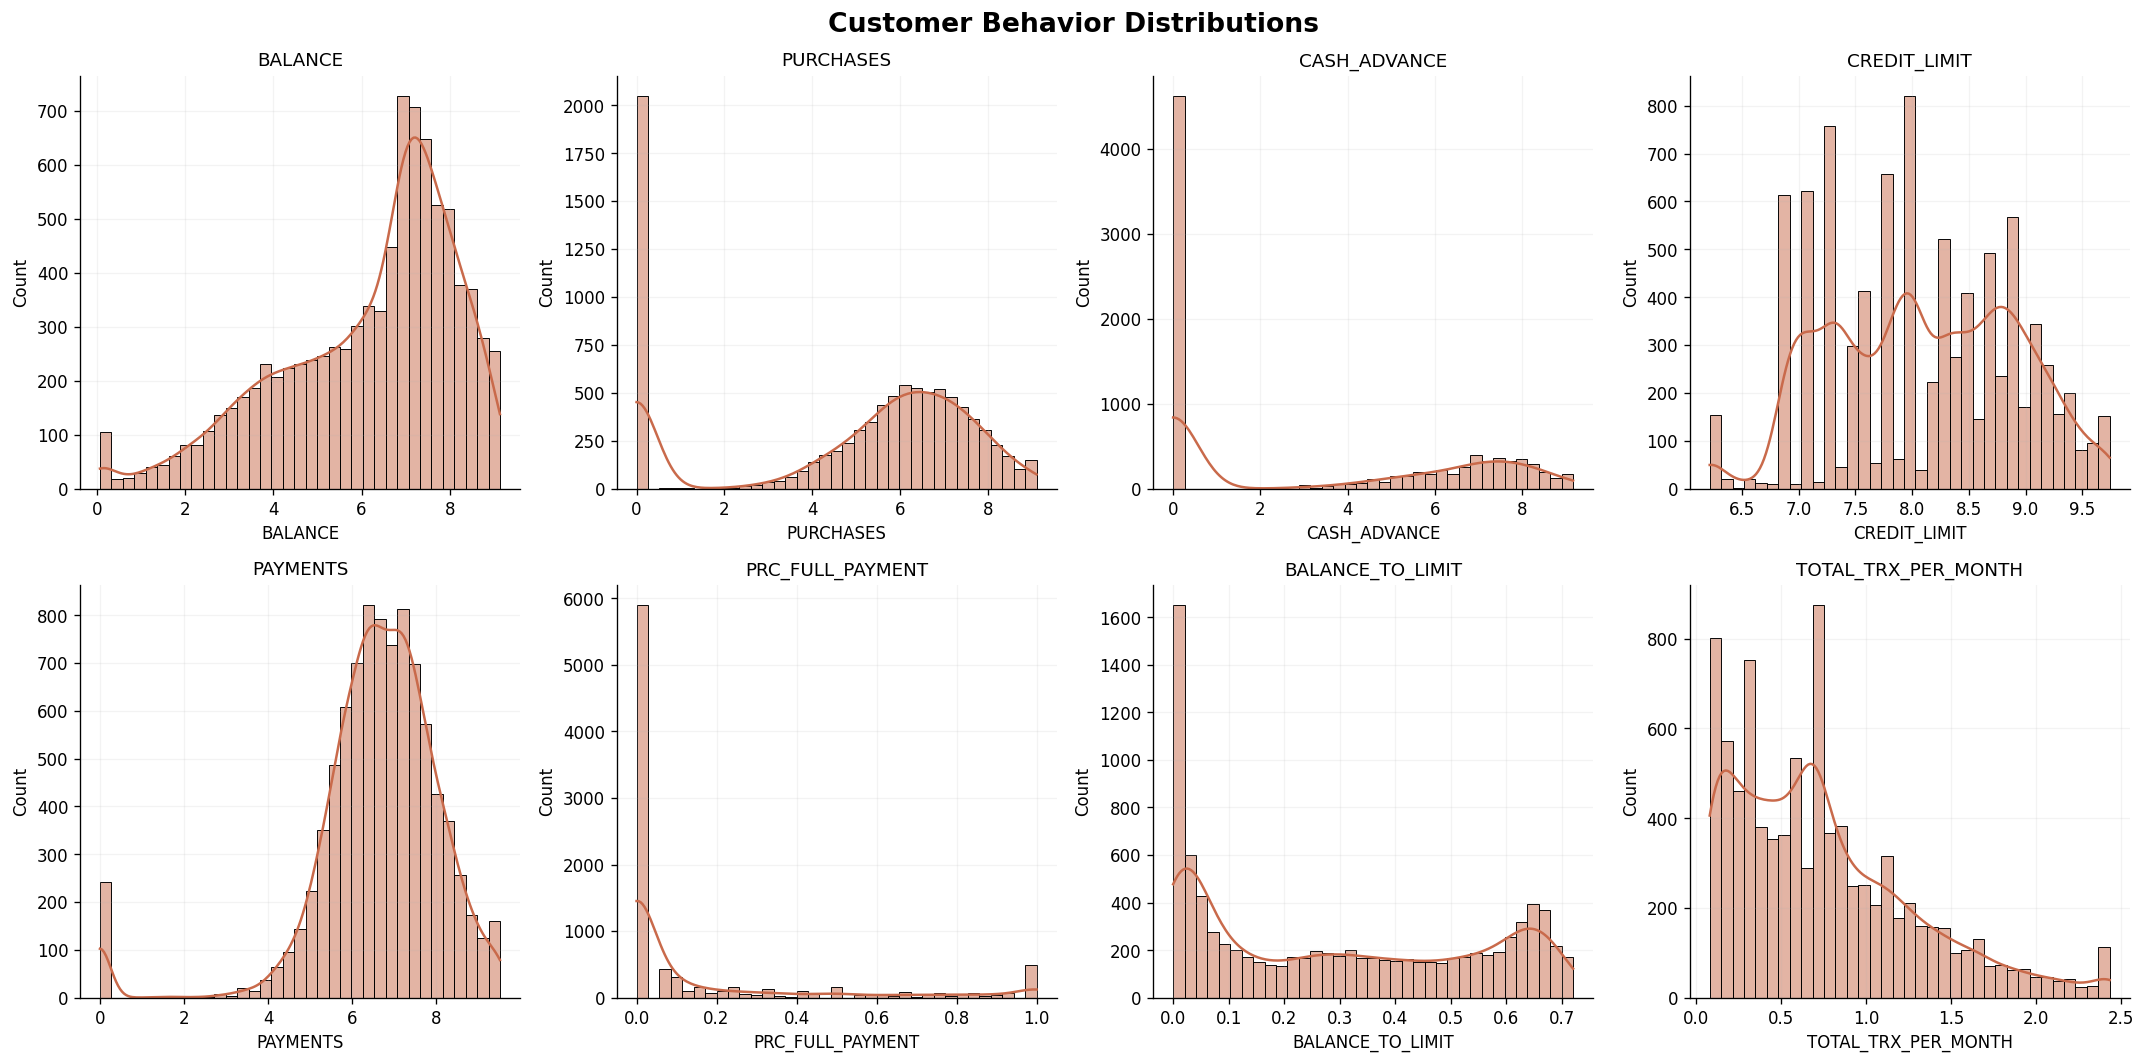

In [45]:
# ============================================================
# 7B. PRESENTATION EDA - DISTRIBUTION GRID
# ============================================================
dist_features = [
    "BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT",
    "PAYMENTS", "PRC_FULL_PAYMENT", "BALANCE_TO_LIMIT", "TOTAL_TRX_PER_MONTH"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, dist_features):
    sns.histplot(fe_ready[col], kde=True, bins=35, ax=ax, color="#c96a4b")
    ax.set_title(col, fontsize=11)
    ax.grid(alpha=0.15)

plt.suptitle("Customer Behavior Distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


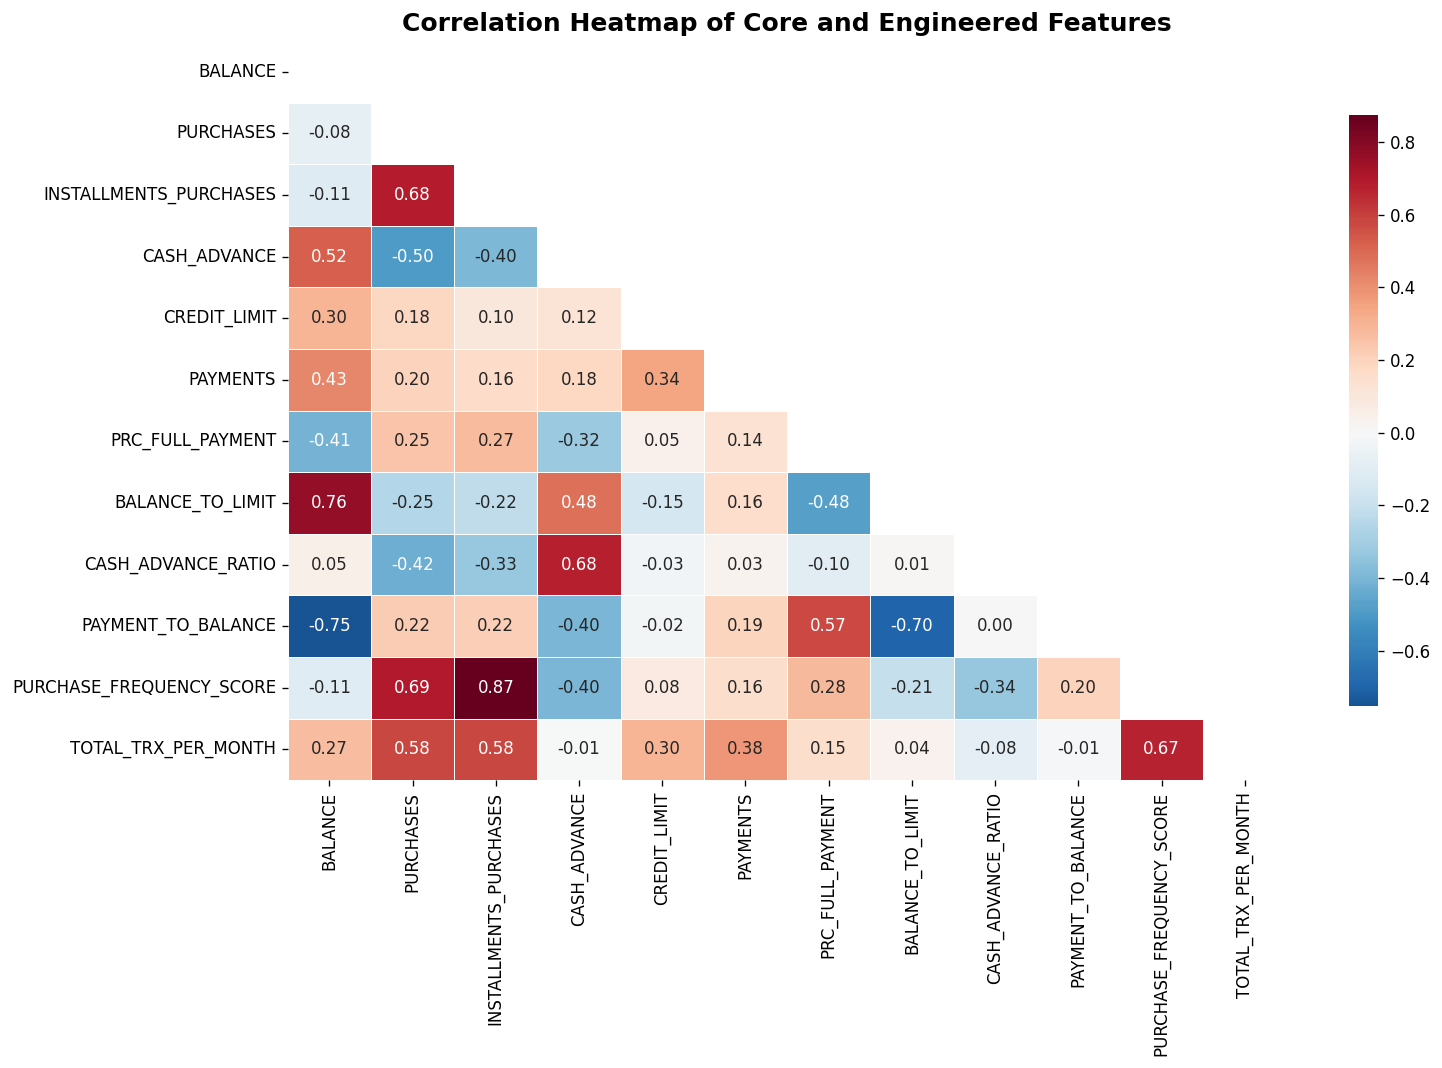

In [46]:
# ============================================================
# 7C. PRESENTATION EDA - CORRELATION HEATMAP
# ============================================================
heatmap_features = [
    "BALANCE", "PURCHASES", "INSTALLMENTS_PURCHASES", "CASH_ADVANCE",
    "CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT",
    "BALANCE_TO_LIMIT", "CASH_ADVANCE_RATIO", "PAYMENT_TO_BALANCE",
    "PURCHASE_FREQUENCY_SCORE",  "TOTAL_TRX_PER_MONTH"
]

fig, ax = plt.subplots(figsize=(13, 9))
available_heatmap_features = [col for col in heatmap_features if col in fe_capped.columns]
corr = fe_capped[available_heatmap_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Correlation Heatmap of Core and Engineered Features", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


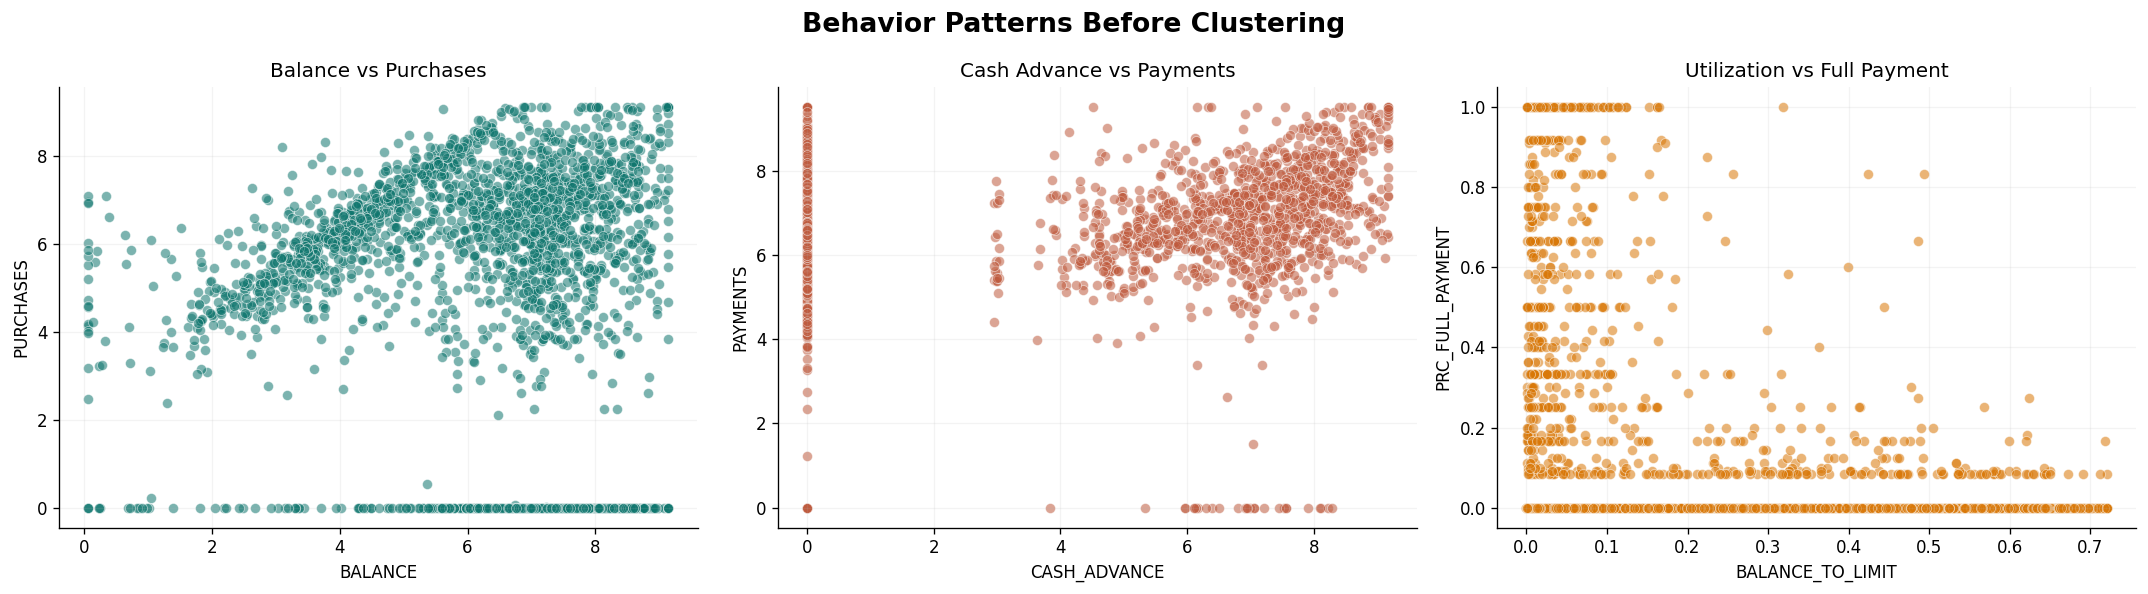

In [ ]:
# ============================================================
# 7D. PRESENTATION EDA - KEY BUSINESS RELATIONSHIPS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=fe_ready.sample(min(2500, len(fe_ready)), random_state=RANDOM_STATE),
                x="BALANCE", y="PURCHASES", alpha=0.55, ax=axes[0], color="#0f766e")
axes[0].set_title("Balance vs Purchases")

sns.scatterplot(data=fe_ready.sample(min(2500, len(fe_ready)), random_state=RANDOM_STATE),
                x="CASH_ADVANCE", y="PAYMENTS", alpha=0.55, ax=axes[1], color="#bf5a3d")
axes[1].set_title("Cash Advance vs Payments")

sns.scatterplot(data=fe_ready.sample(min(2500, len(fe_ready)), random_state=RANDOM_STATE),
                x="BALANCE_TO_LIMIT", y="PRC_FULL_PAYMENT", alpha=0.55, ax=axes[2], color="#d97706")
axes[2].set_title("Utilization vs Full Payment")

for ax in axes:
    ax.grid(alpha=0.15)

plt.suptitle("Behavior Patterns Before Clustering", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### Presentation Note
This richer EDA section is especially useful when the notebook is being used for:

- a project presentation
- a viva or oral discussion
- a submission where the reviewer expects visual reasoning before the modeling stage

It improves interpretability without weakening the stronger modeling decisions in the improved pipeline.


## Step 5 - Scaling and Dimensionality Reduction



In [ ]:
# ============================================================
# 8. SCALING + PCA
# ============================================================
feature_names = fe_ready.columns.tolist()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(fe_ready)

pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cum_var >= 0.90) + 1
n_components_95 = np.argmax(cum_var >= 0.95) + 1

pca_model = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_model = pca_model.fit_transform(X_scaled)

print("Scaled shape:", X_scaled.shape)
print("PCA components for 90% variance:", n_components_90)
print("PCA components for 95% variance:", n_components_95)
print(f"Variance explained by modeling PCA: {pca_model.explained_variance_ratio_.sum():.2%}")


Scaled shape: (8950, 12)
PCA components for 90% variance: 5
PCA components for 95% variance: 6
Variance explained by modeling PCA: 91.00%


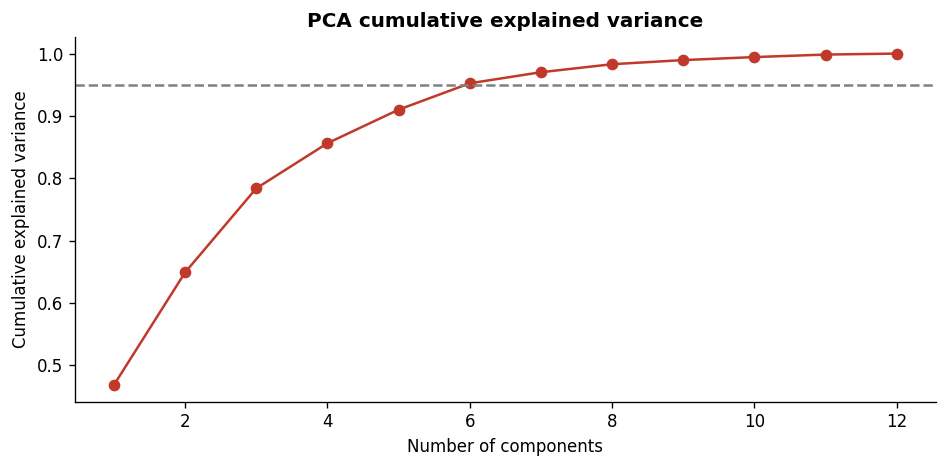

In [ ]:
# ============================================================
# 9. PCA EXPLAINED VARIANCE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker="o", color="#c0392b")
ax.axhline(0.95, linestyle="--", color="gray")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA cumulative explained variance", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 6 - Choose K More Carefully



In [ ]:
# ============================================================
# 10. K SEARCH FOR PARTITION-BASED MODELS
# ============================================================
def evaluate_partition_model(X, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}
    return {
        "silhouette": silhouette_score(X, labels, sample_size=min(3000, len(X)), random_state=RANDOM_STATE),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels)
    }

def rank_ks(X, ks=range(2, 7)):
    rows = []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
        labels = km.fit_predict(X)
        scores = evaluate_partition_model(X, labels)
        rows.append({"k": k, **scores})
    result = pd.DataFrame(rows)
    result["rank_sil"] = result["silhouette"].rank(ascending=False, method="min")
    result["rank_ch"] = result["calinski_harabasz"].rank(ascending=False, method="min")
    result["rank_db"] = result["davies_bouldin"].rank(ascending=True, method="min")
    result["rank_total"] = result["rank_sil"] + result["rank_ch"] + result["rank_db"]
    return result.sort_values(["rank_total", "silhouette"], ascending=[True, False])

k_search = rank_ks(X_model, ks=range(2, 7))
display(k_search)

BEST_K = int(k_search.iloc[0]["k"])
print("Recommended K from ranked metrics:", BEST_K)


,k,silhouette,calinski_harabasz,davies_bouldin,rank_sil,rank_ch,rank_db,rank_total
0,2,0.504400,6655.251416,0.792533,1.0,1.0,1.0,3.0
3,5,0.329184,4704.283460,1.108899,2.0,4.0,3.0,9.0
4,6,0.319624,4429.759125,1.104989,3.0,5.0,2.0,10.0
2,4,0.317582,5057.160285,1.139245,4.0,3.0,4.0,11.0
1,3,0.313863,5556.354429,1.195673,5.0,2.0,5.0,12.0


Recommended K from ranked metrics: 2


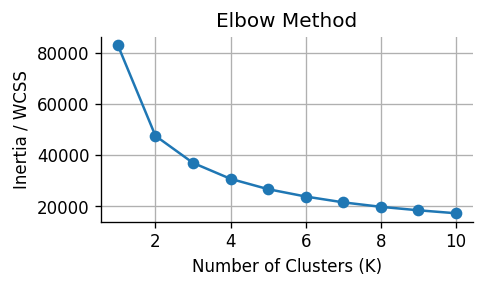

In [47]:
# ============================================================
# 10.5 ELBOW METHOD
# ============================================================

inertia_values = []

ks = range(1, 11)

for k in ks:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=30
    )

    km.fit(X_model)

    inertia_values.append(km.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(4,2))

plt.plot(
    ks,
    inertia_values,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

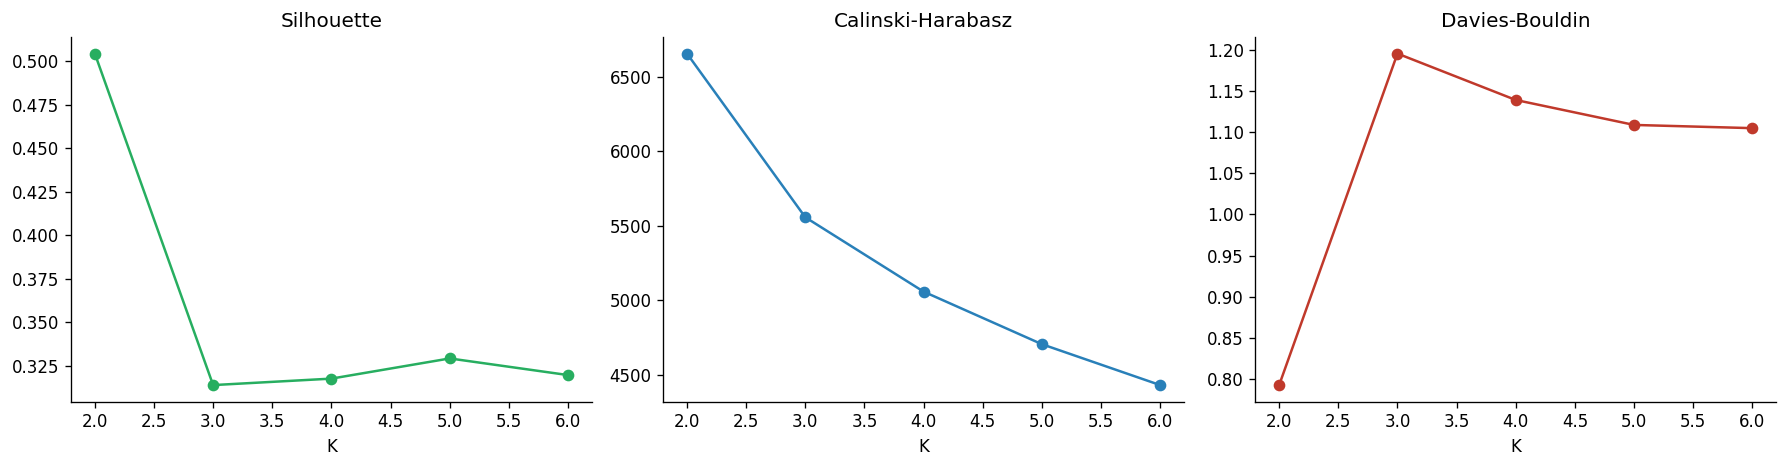

In [ ]:
# ============================================================
# 11. K SEARCH VISUALIZATION
# ============================================================
plot_df = k_search.sort_values("k")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(plot_df["k"], plot_df["silhouette"], marker="o", color="#27ae60")
axes[0].set_title("Silhouette")
axes[0].set_xlabel("K")

axes[1].plot(plot_df["k"], plot_df["calinski_harabasz"], marker="o", color="#2980b9")
axes[1].set_title("Calinski-Harabasz")
axes[1].set_xlabel("K")

axes[2].plot(plot_df["k"], plot_df["davies_bouldin"], marker="o", color="#c0392b")
axes[2].set_title("Davies-Bouldin")
axes[2].set_xlabel("K")

plt.tight_layout()
plt.show()

## Step 7 - Train Multiple Clustering Models



- `KMeans`
- `GaussianMixture`
- `DBSCAN`

In [ ]:
# ============================================================
# 12. TRAIN CLUSTERING MODELS
# ============================================================
models = {
    "KMeans": KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=30),
    "GaussianMixture": GaussianMixture(n_components=BEST_K, random_state=RANDOM_STATE, n_init=10),
}

labels_dict = {}
for name, model in models.items():
    labels = model.fit_predict(X_model)
    labels_dict[name] = labels
    print(f"{name:15s} -> {len(np.unique(labels))} clusters")

dbscan_rows = []
for eps in np.linspace(0.9, 2.2, 8):
    for min_samples in [5, 8, 10]:
        db = DBSCAN(eps=float(eps), min_samples=min_samples)
        labels = db.fit_predict(X_model)
        valid_mask = labels != -1
        n_clusters = len(set(labels[valid_mask]))
        noise_pct = 100 * (labels == -1).mean()
        if n_clusters >= 2 and valid_mask.sum() > 50:
            scores = evaluate_partition_model(X_model[valid_mask], labels[valid_mask])
            dbscan_rows.append({
                "eps": round(float(eps), 2),
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_pct": round(noise_pct, 2),
                **scores
            })

dbscan_search = pd.DataFrame(dbscan_rows).sort_values(
    ["silhouette", "noise_pct"],
    ascending=[False, True]
)
display(dbscan_search.head(10))

if not dbscan_search.empty:
    best_db = dbscan_search.iloc[0]
    dbscan_model = DBSCAN(eps=float(best_db["eps"]), min_samples=int(best_db["min_samples"]))
    labels_dict["DBSCAN"] = dbscan_model.fit_predict(X_model)
    models["DBSCAN"] = dbscan_model


In [ ]:
# ============================================================
# 13. EVALUATION TABLE
# ============================================================
def evaluate_cluster_result(X, labels, include_noise=False):
    labels = np.asarray(labels)
    if include_noise:
        X_eval = X
        y_eval = labels
    else:
        mask = labels != -1
        X_eval = X[mask]
        y_eval = labels[mask]

    if len(np.unique(y_eval)) < 2:
        return np.nan, np.nan, np.nan

    sil = silhouette_score(X_eval, y_eval, sample_size=min(3000, len(X_eval)), random_state=RANDOM_STATE)
    ch = calinski_harabasz_score(X_eval, y_eval)
    db = davies_bouldin_score(X_eval, y_eval)
    return sil, ch, db

rows = []
for name, labels in labels_dict.items():
    labels = np.asarray(labels)
    valid_mask = labels != -1
    cluster_count = len(np.unique(labels[valid_mask])) if valid_mask.any() else 0
    noise_pct = round(100 * (labels == -1).mean(), 2)
    cluster_sizes = pd.Series(labels[valid_mask]).value_counts() if valid_mask.any() else pd.Series(dtype=float)
    min_cluster_pct = round(100 * cluster_sizes.min() / len(labels), 2) if not cluster_sizes.empty else 0
    sil, ch, db = evaluate_cluster_result(X_model, labels, include_noise=False)
    rows.append({
        "algorithm": name,
        "clusters": cluster_count,
        "noise_pct": noise_pct,
        "min_cluster_pct": min_cluster_pct,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db
    })

eval_df = pd.DataFrame(rows).sort_values(
    ["silhouette", "min_cluster_pct", "noise_pct"],
    ascending=[False, False, True]
)
display(eval_df)


In [ ]:
# ============================================================
# 14. FINAL MODEL SELECTION
# ============================================================
deployable_priority = ["KMeans", "GaussianMixture", "DBSCAN"]
candidate_df = eval_df.copy()
candidate_df = candidate_df[candidate_df["min_cluster_pct"] >= 3].copy()
if candidate_df.empty:
    candidate_df = eval_df.copy()

candidate_df["deployable_rank"] = candidate_df["algorithm"].apply(deployable_priority.index)
candidate_df = candidate_df.sort_values(
    ["silhouette", "min_cluster_pct", "noise_pct", "deployable_rank"],
    ascending=[False, False, True, True]
)

FINAL_ALGO = candidate_df.iloc[0]["algorithm"]
final_labels = np.asarray(labels_dict[FINAL_ALGO])
print("Final algorithm:", FINAL_ALGO)
display(candidate_df)

## Step 8 - Visualize Segments



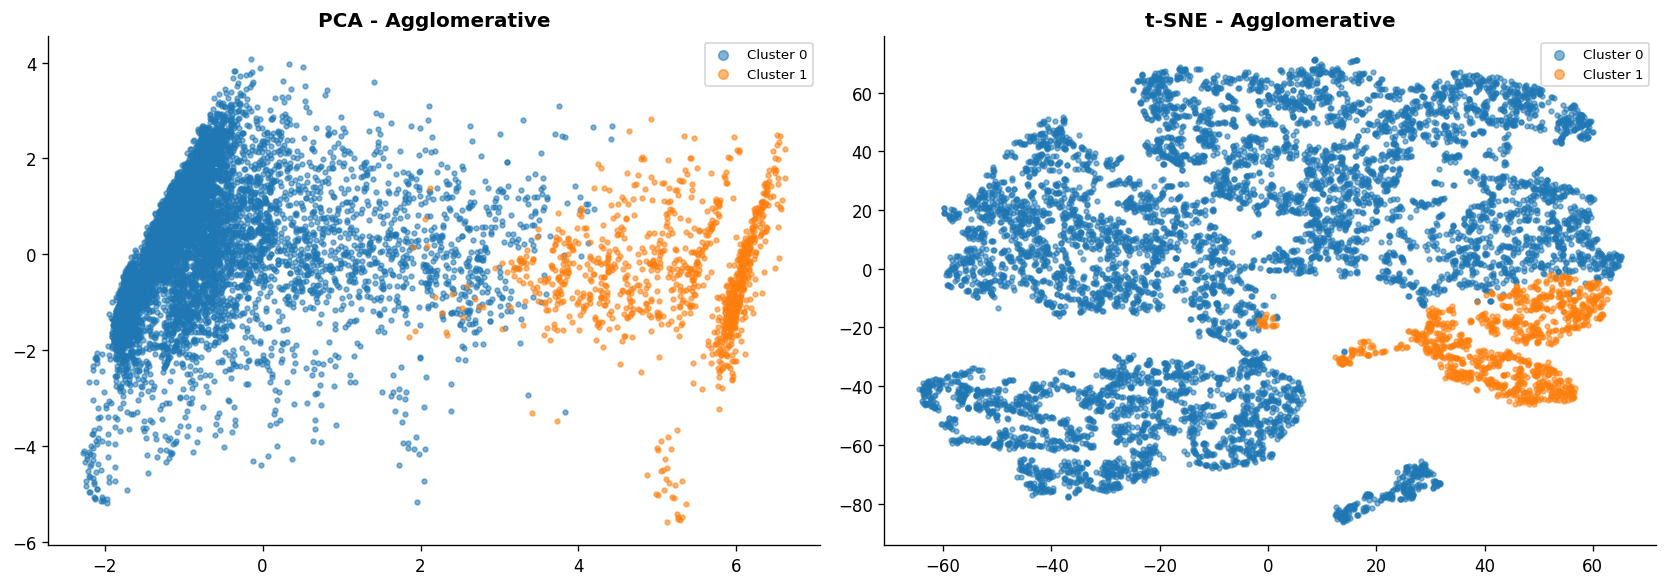

In [ ]:
# ============================================================
# 15. 2D VISUALIZATION
# ============================================================
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
tsne_input = X_pca_full[:, :min(10, X_pca_full.shape[1])]
tsne_2d = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    max_iter=1000
).fit_transform(tsne_input)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, coords, title in [(axes[0], pca_2d, "PCA"), (axes[1], tsne_2d, "t-SNE")]:
    for lbl in sorted(np.unique(final_labels)):
        mask = final_labels == lbl
        color = "lightgray" if lbl == -1 else COLORS[int(lbl) % len(COLORS)]
        label = "Noise" if lbl == -1 else f"Cluster {int(lbl)}"
        ax.scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.55, color=color, label=label)
    ax.set_title(f"{title} - {FINAL_ALGO}", fontweight="bold")
    ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()


## Step 9 - Cluster Profiling



In [ ]:
# ============================================================
# 16. PROFILE CLUSTERS
# ============================================================
profile_df = fe_capped.copy()
profile_df["Cluster"] = final_labels
profile_df = profile_df[profile_df["Cluster"] != -1].copy()

profile_features = [
    "BALANCE", "PURCHASES", "INSTALLMENTS_PURCHASES", "CASH_ADVANCE",
    "CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT",
    "BALANCE_TO_LIMIT", "CASH_ADVANCE_RATIO", "PAYMENT_TO_BALANCE",
    "PURCHASE_FREQUENCY_SCORE", "TOTAL_TRX"
]

available_profile_features = [col for col in profile_features if col in profile_df.columns]
profile_mean = profile_df.groupby("Cluster")[available_profile_features].mean().round(3)
profile_median = profile_df.groupby("Cluster")[available_profile_features].median().round(3)
cluster_sizes = profile_df["Cluster"].value_counts().sort_index()

display(profile_mean)
display(profile_median)
print("Cluster sizes:")
display((cluster_sizes.to_frame("count")
         .assign(pct=lambda d: (100 * d["count"] / len(profile_df)).round(2))))


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,BALANCE_TO_LIMIT,CASH_ADVANCE_RATIO,PAYMENT_TO_BALANCE,PURCHASE_FREQUENCY_SCORE,TOTAL_TRX
Cluster,,,,,,,,,,,,
0,6.386,4.665,3.093,3.669,8.079,6.565,0.058,0.328,0.390,1.088,0.393,2.349
1,4.440,6.644,5.291,0.627,8.222,7.039,0.878,0.043,0.172,2.683,0.691,2.812


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,BALANCE_TO_LIMIT,CASH_ADVANCE_RATIO,PAYMENT_TO_BALANCE,PURCHASE_FREQUENCY_SCORE,TOTAL_TRX
Cluster,,,,,,,,,,,,
0,6.968,5.726,3.931,4.53,8.007,6.718,0.000,0.322,0.062,0.659,0.286,2.398
1,4.430,6.741,6.096,0.00,8.294,6.987,0.917,0.022,0.000,2.526,0.786,2.639


Cluster sizes:


,count,pct
Cluster,,
0,7910,88.38
1,1040,11.62


In [ ]:
# ============================================================
# 17. BUSINESS LABELS
# ============================================================
profile_norm = (profile_mean - profile_mean.min()) / (profile_mean.max() - profile_mean.min() + 1e-9)

def assign_business_label(row):
    if row["CASH_ADVANCE_RATIO"] > 0.65 and row["PAYMENT_TO_BALANCE"] < 0.45:
        return "Cash Advance Heavy"
    if row["PRC_FULL_PAYMENT"] > 0.65 and row["PURCHASES"] > 0.55:
        return "Transactors"
    if row["BALANCE_TO_LIMIT"] > 0.7 and row["PAYMENT_TO_BALANCE"] < 0.35:
        return "High-Risk Revolvers"
    if row["PURCHASES"] > 0.65 and row["INSTALLMENTS_PURCHASES"] > 0.55:
        return "Installment Shoppers"
    if row["CREDIT_LIMIT"] > 0.75 and row["PURCHASES"] > 0.6:
        return "Premium Spenders"
    if row["PURCHASES"] < 0.3 and row["TOTAL_TRX"] < 0.3:
        return "Low Activity"
    return "Moderate Users"

business_labels = {cluster: assign_business_label(profile_norm.loc[cluster]) for cluster in profile_norm.index}
print("Assigned labels:")
display(pd.Series(business_labels, name="segment_label"))

Assigned labels:


,segment_label
0,Cash Advance Heavy
1,Transactors


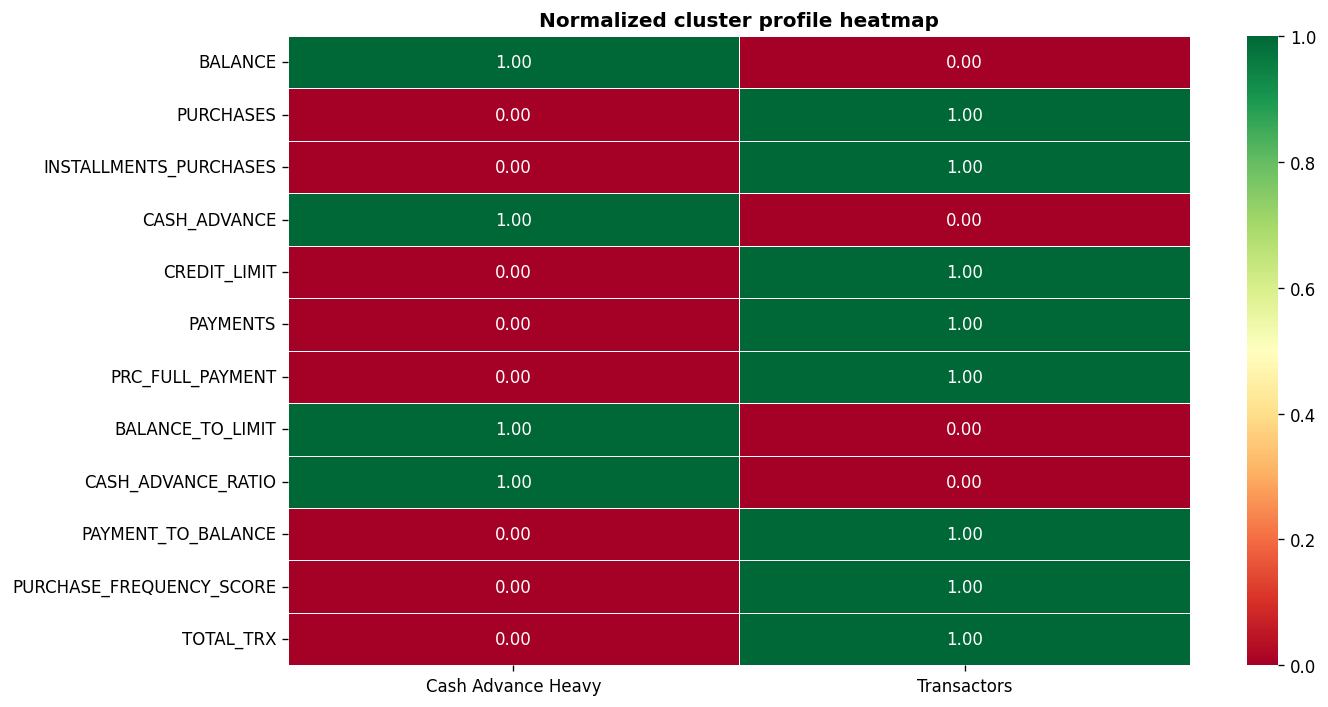

In [ ]:
# ============================================================
# 18. PROFILE HEATMAP
# ============================================================
heatmap_data = profile_norm[profile_features].T
heatmap_data.columns = [business_labels.get(c, f"Cluster {c}") for c in heatmap_data.columns]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="RdYlGn", annot=True, fmt=".2f", linewidths=0.5, vmin=0, vmax=1)
plt.title("Normalized cluster profile heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

## Step 11 - Inference Pipeline for New Customers



In [ ]:
# ============================================================
# 20. INFERENCE HELPERS
# ============================================================
train_cluster_centroids = (
    pd.DataFrame(X_model)
      .assign(Cluster=final_labels)
      .query("Cluster != -1")
      .groupby("Cluster")
      .mean()
)

def apply_preprocessing(df_raw):
    df_step = pd.DataFrame(imputer.transform(df_raw), columns=feature_df.columns, index=df_raw.index)
    df_step = add_features(df_step)
    df_step = apply_log_transform(df_step, log_cols)
    df_step = apply_percentile_bounds(df_step, outlier_bounds)
    df_step = df_step[BEST_FEATURES]
    X_scaled_new = scaler.transform(df_step)
    X_model_new = pca_model.transform(X_scaled_new)
    return df_step, X_model_new

def nearest_centroid_predict(X_new):
    centroid_array = train_cluster_centroids.to_numpy()
    centroid_labels = train_cluster_centroids.index.to_numpy()
    distances = ((centroid_array[None, :, :] - X_new[:, None, :]) ** 2).sum(axis=2) ** 0.5
    return centroid_labels[np.argmin(distances, axis=1)]

def predict_new_customers(df_raw, preferred_model=None):
    _, X_new = apply_preprocessing(df_raw)
    model_name = preferred_model or FINAL_ALGO
    model = models[model_name]

    if hasattr(model, "predict"):
        preds = model.predict(X_new)
    else:
        preds = nearest_centroid_predict(X_new)

    labels = [business_labels.get(int(cluster), f"Cluster {cluster}") for cluster in preds]
    return pd.DataFrame({
        "predicted_cluster": preds,
        "predicted_segment": labels
    }, index=df_raw.index)


In [ ]:
# ============================================================
# 21. EXAMPLE PREDICTION
# ============================================================
new_customer = pd.DataFrame([{
    "BALANCE": 2500,
    "BALANCE_FREQUENCY": 0.9,
    "PURCHASES": 500,
    "ONEOFF_PURCHASES": 300,
    "INSTALLMENTS_PURCHASES": 200,
    "CASH_ADVANCE": 3000,
    "PURCHASES_FREQUENCY": 0.3,
    "ONEOFF_PURCHASES_FREQUENCY": 0.2,
    "PURCHASES_INSTALLMENTS_FREQUENCY": 0.2,
    "CASH_ADVANCE_FREQUENCY": 0.8,
    "CASH_ADVANCE_TRX": 12,
    "PURCHASES_TRX": 5,
    "CREDIT_LIMIT": 5000,
    "PAYMENTS": 400,
    "MINIMUM_PAYMENTS": 200,
    "PRC_FULL_PAYMENT": 0.05,
    "TENURE": 10
}])

display(predict_new_customers(new_customer))

,predicted_cluster,predicted_segment
0,0,Cash Advance Heavy


## Step 12 - Export Results

In [ ]:
# ============================================================
# 22. EXPORT FINAL SEGMENTATION
# ============================================================
export_df = fe_ready.copy()
export_df["Cluster_ID"] = final_labels
export_df["Segment_Label"] = export_df["Cluster_ID"].map(business_labels).fillna("Noise")

if id_col:
    export_df.insert(0, id_col, data[id_col].values)

export_path = Path("credit_card_segments_improved.csv")
export_df.to_csv(export_path, index=False)

print(f"Exported segmentation results to: {export_path.resolve()}")
display(export_df.head())

Exported segmentation results to: /content/credit_card_segments_improved.csv


,CUST_ID,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,BALANCE_TO_LIMIT,PURCHASES_TO_LIMIT,CASH_ADVANCE_RATIO,PAYMENT_TO_BALANCE,PURCHASE_FREQUENCY_SCORE,TOTAL_TRX,Cluster_ID,Segment_Label
0,C10001,3.735304,4.568506,0.000000,6.908755,5.312231,0.000000,0.040047,0.091033,0.000000,1.760646,0.125000,1.098612,0,Cash Advance Heavy
1,C10002,8.071989,0.000000,8.770896,8.853808,8.319725,0.222222,0.376675,0.000000,1.102352,0.824531,0.000000,1.609438,0,Cash Advance Heavy
2,C10003,7.822504,6.651791,0.000000,8.922792,6.434654,0.000000,0.287164,0.098102,0.000000,0.222512,0.500000,2.564949,0,Cash Advance Heavy
3,C10004,7.419183,7.313220,5.331694,8.922792,0.000000,0.000000,0.200647,0.182188,0.116358,0.000000,0.041667,1.098612,0,Cash Advance Heavy
4,C10005,6.707735,2.833213,0.000000,7.090910,6.521114,0.000000,0.519306,0.013234,0.000000,0.603516,0.041667,0.693147,0,Cash Advance Heavy


## Step 13 - Save GUI Pipeline

In [ ]:
# ============================================================
# 23. SAVE MODEL PIPELINE FOR GUI
# ============================================================
import joblib

segmented_result = data.copy()
segmented_result["Cluster"] = final_labels
segmented_result["Segment"] = segmented_result["Cluster"].map(business_labels).fillna("Noise")

plot_df = pd.DataFrame({
    "PCA 1": pca_2d[:, 0],
    "PCA 2": pca_2d[:, 1],
    "Cluster": final_labels,
})
plot_df["Segment"] = plot_df["Cluster"].map(business_labels).fillna("Noise")

pipeline_pack = {
    "raw": data.copy(),
    "ids": data[id_col].copy() if id_col else pd.Series(range(len(data))),
    "numeric_columns": feature_df.columns.tolist(),
    "imputer": imputer,
    "bounds": outlier_bounds,
    "log_cols": log_cols,
    "scaler": scaler,
    "pca": pca_model,
    "model": models[FINAL_ALGO],
    "final_algo": FINAL_ALGO,
    "best_k": BEST_K,
    "k_scores": k_search.copy(),
    "profile": profile_mean.copy(),
    "segment_names": {int(k): v for k, v in business_labels.items()},
    "plot_df": plot_df,
    "result": segmented_result,
    "exported": export_df.copy(),
    "train_cluster_centroids": train_cluster_centroids.copy(),
}

pipeline_path = Path("segmentation_pipeline.joblib")
joblib.dump(pipeline_pack, pipeline_path)

print(f"Saved GUI model pipeline to: {pipeline_path.resolve()}")


Saved GUI model pipeline to: /content/segmentation_pipeline.joblib
